# Movie Data Analysis with PySpark

<hr>

#### 00. Import everything from functions.py file

In [33]:
from functions import *

#### 01. Create and start Spark session

In [2]:
'''create spark session'''

spark = create_spark_session("TMDB-PySpark")

25/04/25 10:48:46 WARN Utils: Your hostname, White resolves to a loopback address: 127.0.1.1; using 172.21.2.26 instead (on interface eth0)
25/04/25 10:48:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/25 10:48:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


#### 03. Load Environment variables and save base url

In [3]:
''' load .env file in this directory'''
load_dotenv()


'''get api key and save the base url'''
api_key = os.getenv('TMDB_API_KEY')

url = 'https://api.themoviedb.org/3/movie'


## STEP 1: Extract Data

### 1.1 Fetch Data

In [4]:
'''list of movies to fetch from API'''

movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397, 
             420818, 24428, 168259, 99861, 284054, 12445, 181808, 
             330457, 351286, 109445, 321612, 260513]


In [5]:
'''Extract data from API using extract_data function'''

%time df_movies = extract_data(url, api_key, movie_ids, spark)

[WARNING] HTTP error for movie ID 0: 404 Client Error: Not Found for url: https://api.themoviedb.org/3/movie/0?api_key=6383d74ea1616df62e4286bc3cb11c82&append_to_response=credits
[INFO] Fetched movie ID 299534 successfully.
[INFO] Fetched movie ID 19995 successfully.
[INFO] Fetched movie ID 140607 successfully.
[INFO] Fetched movie ID 299536 successfully.
[INFO] Fetched movie ID 597 successfully.
[INFO] Fetched movie ID 135397 successfully.
[INFO] Fetched movie ID 420818 successfully.
[INFO] Fetched movie ID 24428 successfully.
[INFO] Fetched movie ID 168259 successfully.
[INFO] Fetched movie ID 99861 successfully.
[INFO] Fetched movie ID 284054 successfully.
[INFO] Fetched movie ID 12445 successfully.
[INFO] Fetched movie ID 181808 successfully.
[INFO] Fetched movie ID 330457 successfully.
[INFO] Fetched movie ID 351286 successfully.
[INFO] Fetched movie ID 109445 successfully.
[INFO] Fetched movie ID 321612 successfully.
[INFO] Fetched movie ID 260513 successfully.


CPU times: user 279 ms, sys: 46.3 ms, total: 325 ms
Wall time: 23.5 s


### 1.2 Explore Data

In [6]:
df_movies.toPandas().head(1)

25/04/25 11:01:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,adult,backdrop_path,belongs_to_collection,budget,credits,genres,homepage,id,imdb_id,origin_country,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"(/zuW6fOiusv4X9nnW3paHGfXcSll.jpg, 86311, The ...",356000000,"([(False, 493, Tony Stark / Iron Man, 5e85cd73...","[(12, Adventure), (878, Science Fiction), (28,...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],...,2019-04-24,2799439100,181,"[(English, en, English), (Japanese, ja, 日本語), ...",Released,Avenge the fallen.,Avengers: Endgame,False,8.237,26258


<hr>

## STEP 2: Data Cleaning & Preprocessing

#### Data Cleaning and Preprocessing Summary

The `clean_data` function prepares the movie dataset for analysis through the following key steps:

1.  **Drops irrelevant columns.**
2.  **Parses JSON-like fields** for genres, collection, production details, and spoken languages, separating multiple values with "|".
3.  **Extracts key credit information**, including cast, cast size, crew size, and director(s) (separated by "|").
4.  **Rounds `popularity` and `vote_average` to 2 decimal places.**
5.  **Converts `release_date` to datetime.**
6.  **Creates `budget_million_usd` and `revenue_million_usd` (rounded to 2dp).**
7.  **Removes duplicate rows.**
8.  **Filters for "Released" movies and drops the `status` column.**
9.  **Reorders columns** for consistency.

This process ensures a clean, structured, and analysis-ready dataset.

In [8]:
'''Clean Dataframe'''

df_movies = clean_data(df_movies)

In [9]:
df_movies.toPandas().head(2)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_million_usd,revenue_million_usd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.42,Marvel Studios,...,8.24,110.68,149,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo|Anthony Russo,724
1,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.22,Lucasfilm Ltd.|Bad Robot,...,7.26,16.35,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,182,J.J. Abrams,257


## STEP 3: Key Performance Indicators Analysis

#### 3.1 KPI Indicators Function Summary

The `kpi_indicators` function enhances the DataFrame by adding two financial Key Performance Indicators (KPIs):

1.  **Calculates 'profit'**: This new column represents the difference between the movie's revenue and its budget, rounded to two decimal places.
2.  **Calculates 'roi' (Return on Investment)**: This column indicates the profitability of a movie as the ratio of revenue to budget, rounded to two decimal places. It handles cases with zero budget by assigning a `None` value to avoid division by zero.

By adding these columns, the function facilitates direct analysis of movie profitability and investment efficiency within the DataFrame.

In [10]:
'''KPI Analysis'''

#add kpi indicators
df_movies = kpi_indicators(df_movies)

<hr>

#### 3.2 KPI Analysis Execution

This section performs a Key Performance Indicator (KPI) analysis on the cleaned movie dataset (`df_movies`) using the `rank_movies_spark` function. It identifies the top 3 movies for the following metrics:

* **Highest Revenue:** Displays the top 3 movies with the highest `revenue_million_usd`.
* **Highest Budget:** Shows the top 3 movies with the largest `budget_million_usd`.
* **Highest Profit:** Calculates profit (`revenue_million_usd` - `budget_million_usd`) and displays the top 3 most profitable movies.
* **Lowest Profit:** Calculates profit and displays the top 3 least profitable movies.
* **Highest ROI:** Calculates Return on Investment (`revenue_million_usd` / `budget_million_usd`) for movies with a budget of at least `$10 million` and shows the top 3 with the highest ROI.
* **Lowest ROI:** Calculates ROI for movies with a budget of at least `$10 million` and shows the top 3 with the lowest ROI.
* **Most Voted Movies:** Displays the top 3 movies with the highest `vote_count`.
* **Highest Rated Movies:** Shows the top 3 movies with the highest `vote_average`, considering only movies with at least 10 votes.
* **Lowest Rated Movies:** Shows the top 3 movies with the lowest `vote_average`, considering only movies with at least 10 votes.
* **Most Popular Movies:** Displays the top 3 movies with the highest `popularity` score.

The results for each KPI are printed to the console, showcasing the top-performing movies based on the specified criteria.

In [11]:
'''KPI Analysis'''

# Highest Revenue
highest_revenue = rank_movies_spark(df_movies, sort_by="revenue_million_usd", ascending=False)
print("Highest Revenue Movies:")
highest_revenue.show()

# Highest Budget
highest_budget = rank_movies_spark(df_movies, sort_by="budget_million_usd", ascending=False)
print("\nHighest Budget Movies:")
highest_budget.show()

# Highest Profit (Revenue - Budget)
highest_profit = rank_movies_spark(df_movies.withColumn("profit", col("revenue_million_usd") - col("budget_million_usd")), sort_by="profit", ascending=False)
print("\nHighest Profit Movies:")
highest_profit.show()

# Lowest Profit (Revenue - Budget)
lowest_profit = rank_movies_spark(df_movies.withColumn("profit", col("revenue_million_usd") - col("budget_million_usd")), sort_by="profit", ascending=True)
print("\nLowest Profit Movies:")
lowest_profit.show()

# Highest ROI (Revenue / Budget) (only movies with Budget ≥ 10M)
highest_roi = rank_movies_spark(df_movies, sort_by="roi", ascending=False, min_budget_million_usd=10.0)
print("\nHighest ROI Movies (Budget >= 10M):")
highest_roi.show()

# Lowest ROI (only movies with Budget ≥ 10M)
lowest_roi = rank_movies_spark(df_movies, sort_by="roi", ascending=True, min_budget_million_usd=10.0)
print("\nLowest ROI Movies (Budget >= 10M):")
lowest_roi.show()

# Most Voted Movies
most_voted = rank_movies_spark(df_movies, sort_by="vote_count", ascending=False)
print("\nMost Voted Movies:")
most_voted.show()

# Highest Rated Movies (only movies with ≥10 votes)
highest_rated = rank_movies_spark(df_movies, sort_by="vote_average", ascending=False, min_votes=10)
print("\nHighest Rated Movies (>= 10 votes):")
highest_rated.show()

# Lowest Rated Movies (only movies with ≥10 votes)
lowest_rated = rank_movies_spark(df_movies, sort_by="vote_average", ascending=True, min_votes=10)
print("\nLowest Rated Movies (>= 10 votes):")
lowest_rated.show()

# Most Popular Movies
most_popular = rank_movies_spark(df_movies, sort_by="popularity", ascending=False)
print("\nMost Popular Movies:")
most_popular.show()

Highest Revenue Movies:


+-----------------+-------------------+
|            title|revenue_million_usd|
+-----------------+-------------------+
|           Avatar|            2923.71|
|Avengers: Endgame|            2799.44|
|          Titanic|            2264.16|
+-----------------+-------------------+


Highest Budget Movies:


+--------------------+------------------+
|               title|budget_million_usd|
+--------------------+------------------+
|Avengers: Age of ...|             365.0|
|   Avengers: Endgame|             356.0|
|Avengers: Infinit...|             300.0|
+--------------------+------------------+


Highest Profit Movies:


+-----------------+-------+
|            title| profit|
+-----------------+-------+
|           Avatar|2686.71|
|Avengers: Endgame|2443.44|
|          Titanic|2064.16|
+-----------------+-------+


Lowest Profit Movies:


+--------------------+-------+
|               title| profit|
+--------------------+-------+
|Avengers: Age of ...| 1040.4|
|       Incredibles 2|1042.81|
|Beauty and the Beast|1106.12|
+--------------------+-------+


Highest ROI Movies (Budget >= 10M):


...

+--------------------+----------+
|               title|vote_count|
+--------------------+----------+
|              Avatar|     32166|
|        The Avengers|     31639|
|Avengers: Infinit...|     30442|
+--------------------+----------+


Highest Rated Movies (>= 10 votes):


+--------------------+------------+
|               title|vote_average|
+--------------------+------------+
|   Avengers: Endgame|        8.24|
|Avengers: Infinit...|        8.24|
|Harry Potter and ...|         8.1|
+--------------------+------------+


Lowest Rated Movies (>= 10 votes):


+--------------------+------------+
|               title|vote_average|
+--------------------+------------+
|Jurassic World: F...|        6.54|
|      Jurassic World|        6.69|
|Star Wars: The La...|        6.78|
+--------------------+------------+


Most Popular Movies:


[Stage 32:===========================================>              (3 + 1) / 4]

+--------------------+----------+
|               title|popularity|
+--------------------+----------+
|Avengers: Infinit...|    110.68|
|       The Lion King|      79.4|
|Beauty and the Beast|     77.88|
+--------------------+----------+



<hr>

#### 3.3 Advanced Filtering

In [12]:
'''Find movies with specific actors'''

print("Best-Rated Science Fiction Action Movies Starring Bruce Willis:")
bruce_willis_movie(df_movies)

print("\nMovies Starring Uma Thurman Directed by Quentin Tarantino (Sorted by Runtime):")
uma_tarentino(df_movies)

Best-Rated Science Fiction Action Movies Starring Bruce Willis:


[Stage 35:>                                                         (0 + 4) / 4]

+-----+------------+
|title|vote_average|
+-----+------------+
+-----+------------+


Movies Starring Uma Thurman Directed by Quentin Tarantino (Sorted by Runtime):


[Stage 36:>                                                         (0 + 4) / 4]

+-----+-------+
|title|runtime|
+-----+-------+
+-----+-------+



<hr>

#### 3.4 Franchise Vs Standalone Movies

In [14]:
'''Comparing Franchises to Standalones'''

print("Comparing Franchise vs. Standalone Movie Performance:")
franchise_vs_standalone_performance(df_movies)



Comparing Franchise vs. Standalone Movie Performance:


[Stage 37:>                                                         (0 + 4) / 4]

+------------+-----------------------+----------+----------------------+--------------+----------------+
|is_franchise|avg_revenue_million_usd|median_roi|avg_budget_million_usd|avg_popularity|avg_vote_average|
+------------+-----------------------+----------+----------------------+--------------+----------------+
|Franchise   |1682.64                |7.71      |219.88                |41.29         |7.38            |
|Standalone  |1765.14                |7.91      |180.0                 |61.17         |7.44            |
+------------+-----------------------+----------+----------------------+--------------+----------------+



<hr>

In [15]:
'''Most successful franchises'''


print("Most Successful Movie Franchises (by Total Revenue):")
successful_franchises(df_movies, top_n=5) # You can change top_n to show more or fewer franchises


Most Successful Movie Franchises (by Total Revenue):


[Stage 43:==============>                                           (1 + 3) / 4]

+------------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|belongs_to_collection   |num_movies|total_budget_million_usd|avg_budget_million_usd|total_revenue_million_usd|avg_revenue_million_usd|avg_vote_average|
+------------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|The Avengers Collection |4         |1241.0                  |310.25                |7776.08                  |1944.02                |7.87            |
|Star Wars Collection    |2         |445.0                   |222.5                 |3400.92                  |1700.46                |7.02            |
|Jurassic Park Collection|2         |320.0                   |160.0                 |2982.01                  |1491.01                |6.62            |
|Avatar Collection       |1         |237.0                   |237.0               

<hr>

In [16]:
'''Most Successful Directors'''
print("Most Successful Directors:")
successful_directors(df_movies, top_n=5) # You can adjust top_n as needed

Most Successful Directors:


[Stage 49:===========================================>              (3 + 1) / 4]

+-----------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|director               |num_movies|total_budget_million_usd|avg_budget_million_usd|total_revenue_million_usd|avg_revenue_million_usd|avg_vote_average|
+-----------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|Anthony Russo|Joe Russo|1         |356.0                   |356.0                 |2799.44                  |2799.44                |8.24            |
|James Cameron          |2         |437.0                   |218.5                 |5187.87                  |2593.94                |7.75            |
|J.J. Abrams            |1         |245.0                   |245.0                 |2068.22                  |2068.22                |7.26            |
|Joe Russo|Anthony Russo|1         |300.0                   |300.0                 |2052

## STEP 4: Visualizations

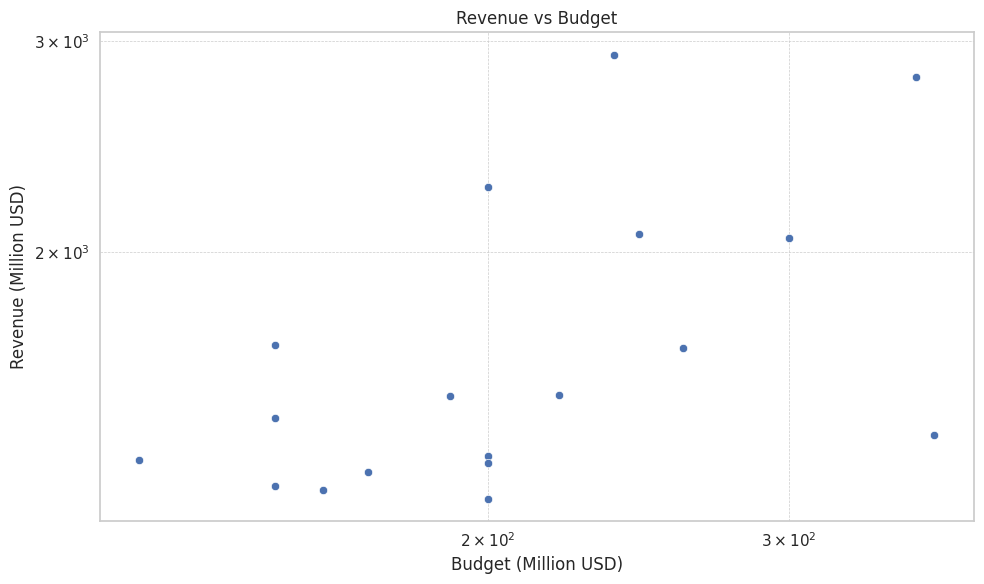

In [34]:
'''View Revenue vs Budget'''

plot_revenue_vs_budget(df_movies)


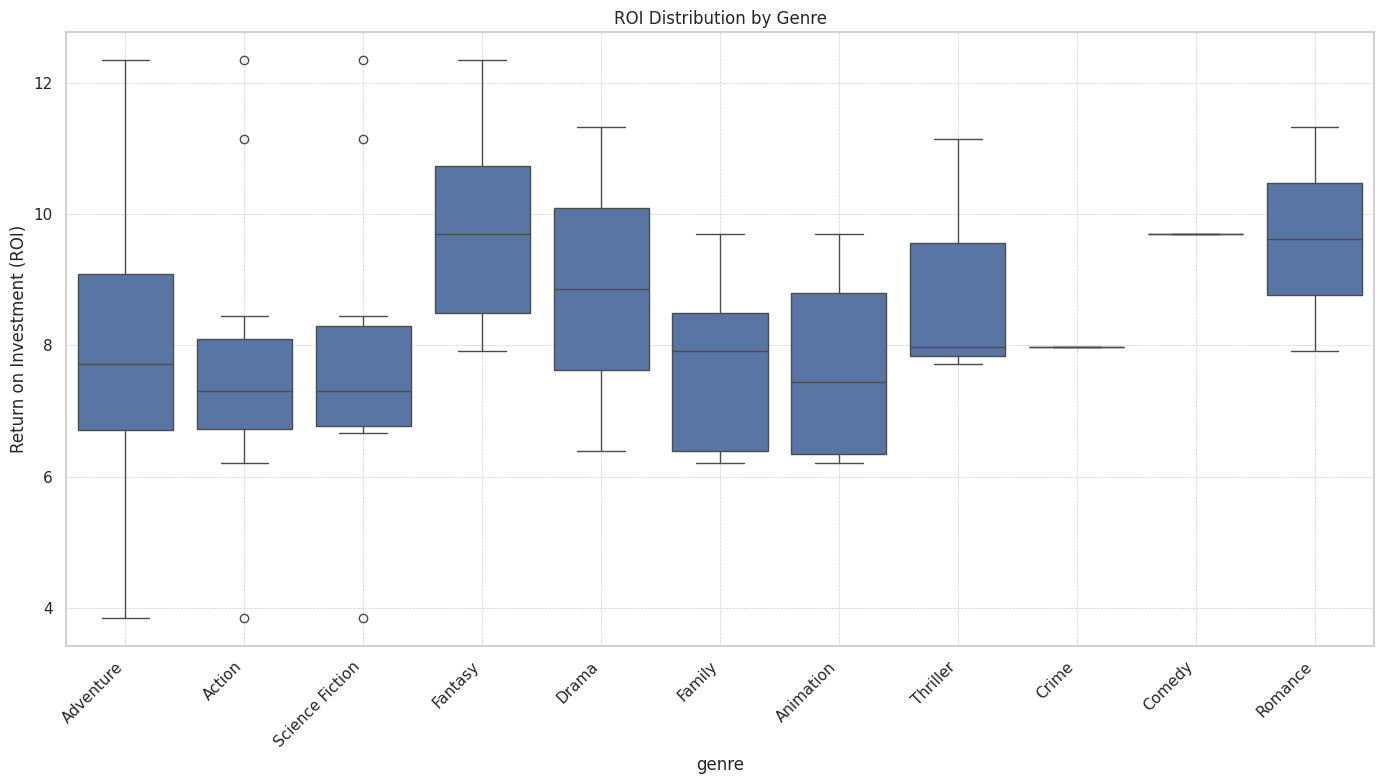

In [35]:
"""View the return on investment distrubution per genre"""

plot_roi_distribution_by_genre(df_movies)

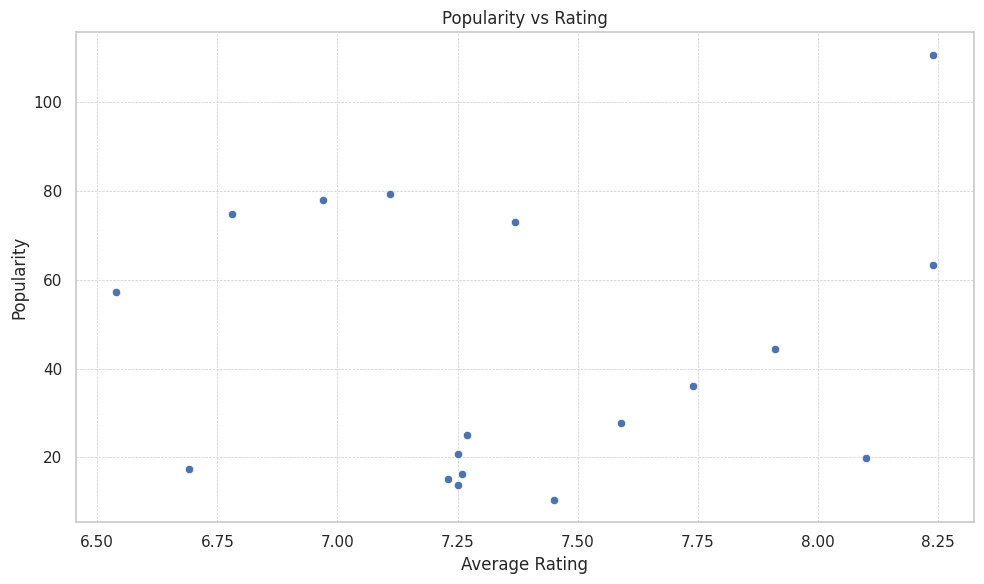

In [36]:
""" View rhe popularity vs Rating"""

plot_popularity_vs_rating(df_movies)

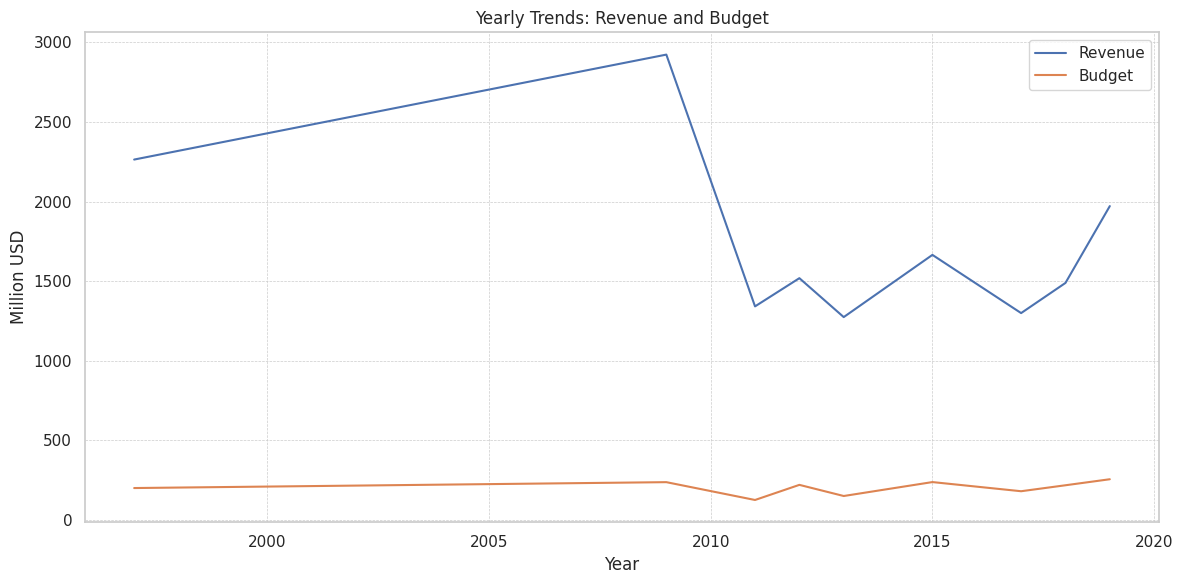

In [37]:
"""View the yearly box office trends"""

plot_yearly_trends(df_movies)

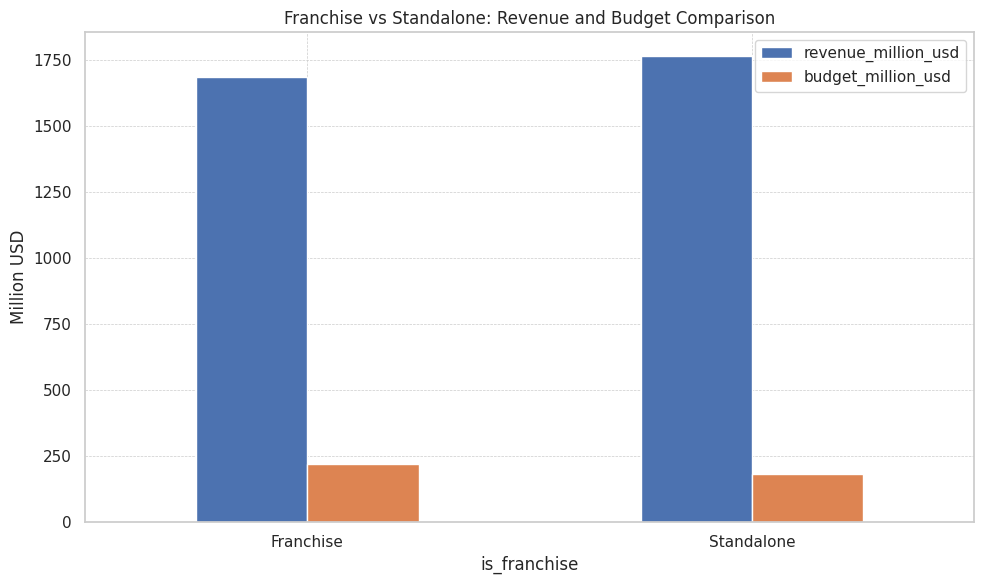

In [38]:
"""View Franchise vs Standalone"""

plot_franchise_vs_standalone_success(df_movies)